In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks


In [2]:
df = pd.read_csv('Final_df.csv', index_col=0)

df_train = df[df['isTrain'] == True]

Y = df_train['target']
X = df_train.drop(columns=['target', 'isTrain', 'address', 'address_rus', 'geometry', 'buffer', 'poi_amenities'])

categorical_features = ['city', 'atm_group']
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

Заполним пропуски и приведем распределение к нормальному

In [4]:
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = QuantileTransformer(output_distribution='normal')
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)


In [6]:
model = models.Sequential([
    layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),
    
    layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),
    
    layers.Dense(1) 
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)


Callbacks

In [7]:
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

In [9]:
history = model.fit(
    X_train_scaled, y_train.values,  
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9275 - mae: 0.5709 - val_loss: 0.2762 - val_mae: 0.1041 - learning_rate: 0.0010
Epoch 2/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4276 - mae: 0.3266 - val_loss: 0.2671 - val_mae: 0.1350 - learning_rate: 0.0010
Epoch 3/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3372 - mae: 0.2416 - val_loss: 0.2438 - val_mae: 0.1063 - learning_rate: 0.0010
Epoch 4/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2853 - mae: 0.1914 - val_loss: 0.2216 - val_mae: 0.0777 - learning_rate: 0.0010
Epoch 5/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2442 - mae: 0.1475 - val_loss: 0.2006 - val_mae: 0.0552 - learning_rate: 0.0010
Epoch 6/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2139 - mae: 0.1170 - val_loss: 0.1826 - val_mae: 0.0486 - learning_rate: 0.0010
Epoch 7/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1902 - mae: 0.0982 - val_loss: 0.1659 - val_mae: 0.0452 - learning_rate: 0.0010

In [10]:
y_pred_dl = model.predict(X_test_scaled).flatten()

mse_dl = mean_squared_error(y_test, y_pred_dl)
rmse_dl = np.sqrt(mse_dl)
r2_dl = r2_score(y_test, y_pred_dl)

print("\nРезультаты на тестовой выборке для нейронной сети:")
print("MSE:", mse_dl)
print("RMSE:", rmse_dl)
print("R^2:", r2_dl)


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step

Результаты на тестовой выборке для нейронной сети:
MSE: 0.0022835009087481097
RMSE: 0.04778599071640254
R^2: 0.6992099922631256


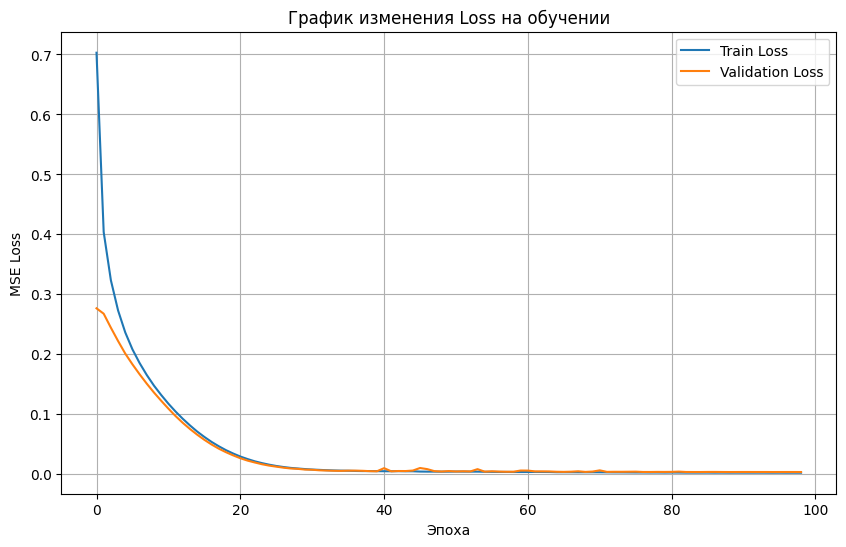

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('График изменения Loss на обучении')
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


Оптимизатор с косинусным спадом скорости обучени

In [12]:
improved_model = models.Sequential([
    layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.5),

    layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.4),

    layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.3),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.2),

    layers.Dense(1)
])


In [13]:
initial_learning_rate = 0.001
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=1000
)

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='mse',
    metrics=['mae']
)


In [ ]:
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)


In [14]:
improved_history = improved_model.fit(
    X_train_scaled, y_train.values,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6829 - mae: 0.6335 - val_loss: 0.7920 - val_mae: 0.2685 - learning_rate: 9.9228e-04
Epoch 2/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9232 - mae: 0.3568 - val_loss: 0.6831 - val_mae: 0.1056 - learning_rate: 9.6937e-04
Epoch 3/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8090 - mae: 0.2964 - val_loss: 0.6445 - val_mae: 0.0833 - learning_rate: 9.3196e-04
Epoch 4/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7412 - mae: 0.2599 - val_loss: 0.6104 - val_mae: 0.0694 - learning_rate: 8.8122e-04
Epoch 5/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6796 - mae: 0.2236 - val_loss: 0.5783 - val_mae: 0.0623 - learning_rate: 8.1871e-04
Epoch 6/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6332 - mae: 0.2008 - val_loss: 0.5482 - val_mae: 0.0554 - learning_rate: 7.4636e-04
Epoch 7/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5912 - mae: 0.1789 - val_loss: 0.5207 - val_mae: 0.0495 - learning_ra

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Результаты на тестовой выборке для улучшенной нейронной сети:
MSE: 0.07912972398426876
RMSE: 0.2813000604057325
R^2: -9.423219101101065


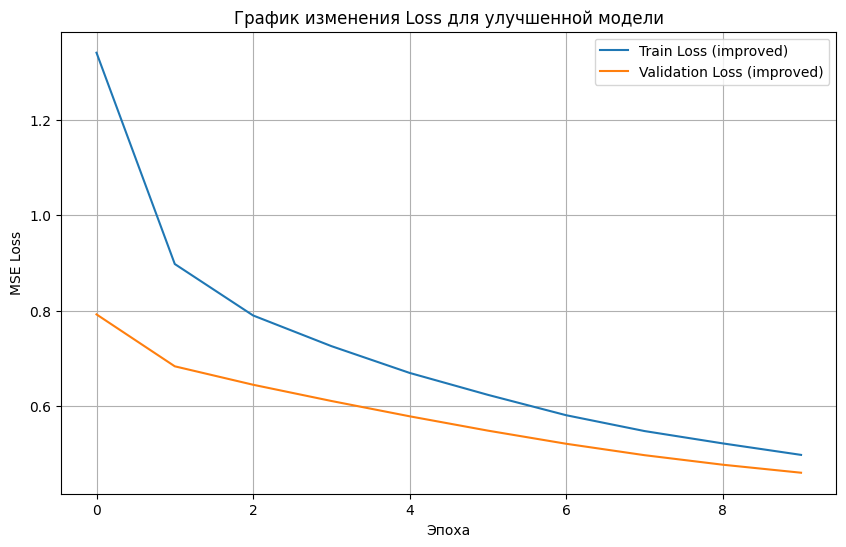

In [15]:
y_pred_improved = improved_model.predict(X_test_scaled).flatten()

mse_improved = mean_squared_error(y_test, y_pred_improved)
rmse_improved = np.sqrt(mse_improved)
r2_improved = r2_score(y_test, y_pred_improved)

print("\nРезультаты на тестовой выборке для улучшенной нейронной сети:")
print("MSE:", mse_improved)
print("RMSE:", rmse_improved)
print("R^2:", r2_improved)

plt.figure(figsize=(10, 6))
plt.plot(improved_history.history['loss'], label='Train Loss (improved)')
plt.plot(improved_history.history['val_loss'], label='Validation Loss (improved)')
plt.title('График изменения Loss для улучшенной модели')
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


TabNet —— у нас всеж табличные данные

In [16]:
pip install pytorch-tabnet



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
from pytorch_tabnet.tab_model import TabNetRegressor
import torch


In [19]:
y_train_np = y_train.values.reshape(-1, 1)
y_test_np = y_test.values.reshape(-1, 1)


In [20]:
tabnet_model = TabNetRegressor(
    n_d=8, n_a=8,
    n_steps=3,   
    gamma=1.5,   
    lambda_sparse=1e-3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    verbose=10,
    seed=42
)

tabnet_model.fit(
    X_train=X_train_scaled, y_train=y_train_np,
    eval_set=[(X_test_scaled, y_test_np)],
    eval_name=['test'],
    eval_metric=['rmse'],
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)


/opt/homebrew/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 3.47109 | test_rmse: 1.15762 |  0:00:00s
epoch 10 | loss: 0.02059 | test_rmse: 2.15301 |  0:00:05s
epoch 20 | loss: 0.00846 | test_rmse: 0.35483 |  0:00:10s
epoch 30 | loss: 0.0078  | test_rmse: 0.16873 |  0:00:15s
epoch 40 | loss: 0.00753 | test_rmse: 0.11849 |  0:00:20s
epoch 50 | loss: 0.00723 | test_rmse: 0.14474 |  0:00:25s
epoch 60 | loss: 0.00679 | test_rmse: 0.09805 |  0:00:31s
epoch 70 | loss: 0.00612 | test_rmse: 0.11522 |  0:00:36s

Early stopping occurred at epoch 79 with best_epoch = 59 and best_test_rmse = 0.09428


/opt/homebrew/lib/python3.11/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [21]:
y_pred_tabnet = tabnet_model.predict(X_test_scaled).flatten()

mse_tabnet = mean_squared_error(y_test, y_pred_tabnet)
rmse_tabnet = np.sqrt(mse_tabnet)
r2_tabnet = r2_score(y_test, y_pred_tabnet)

print("\nРезультаты на тестовой выборке для базового TabNet:")
print("MSE:", mse_tabnet)
print("RMSE:", rmse_tabnet)
print("R^2:", r2_tabnet)



Результаты на тестовой выборке для базового TabNet:
MSE: 0.008889073876082192
RMSE: 0.09428188519584338
R^2: -0.17089710352961718


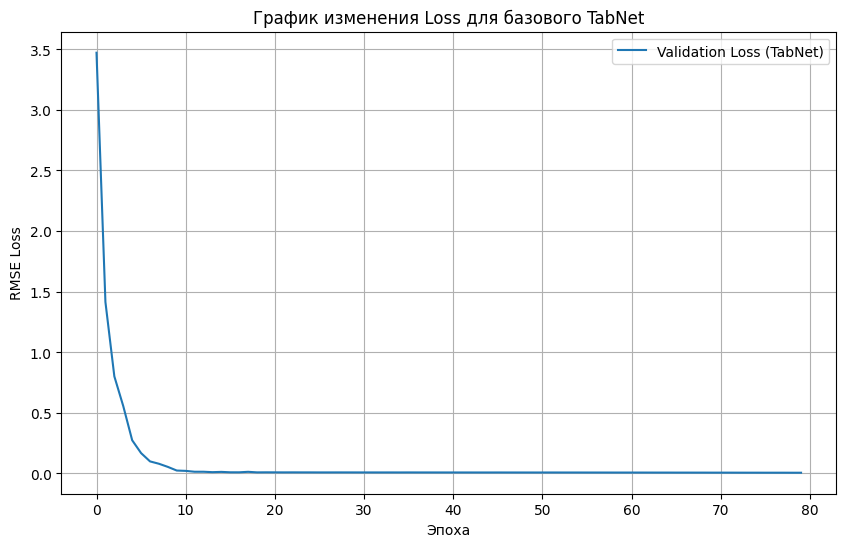

In [22]:
losses = tabnet_model.history['loss']

plt.figure(figsize=(10, 6))
plt.plot(losses, label='Validation Loss (TabNet)')
plt.title('График изменения Loss для базового TabNet')
plt.xlabel('Эпоха')
plt.ylabel('RMSE Loss')
plt.legend()
plt.grid(True)
plt.show()


Попытки улучшить

In [23]:
tabnet_improved = TabNetRegressor(
    n_d=32, n_a=32,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-2,
    optimizer_fn=torch.optim.AdamW,  # улучшенный оптимизатор
    optimizer_params=dict(lr=0.005, weight_decay=1e-5),
    verbose=10,
    seed=42
)

tabnet_improved.fit(
    X_train=X_train_scaled, y_train=y_train_np,
    eval_set=[(X_test_scaled, y_test_np)],
    eval_name=['test'],
    eval_metric=['rmse'],
    max_epochs=300,
    patience=30,
    batch_size=512,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)


/opt/homebrew/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 3.00479 | test_rmse: 4.63918 |  0:00:00s
epoch 10 | loss: 0.2571  | test_rmse: 4.01343 |  0:00:09s
epoch 20 | loss: 0.02389 | test_rmse: 0.84549 |  0:00:18s
epoch 30 | loss: 0.01408 | test_rmse: 0.09494 |  0:00:27s
epoch 40 | loss: 0.0135  | test_rmse: 0.09799 |  0:00:36s
epoch 50 | loss: 0.01231 | test_rmse: 0.14028 |  0:00:45s
epoch 60 | loss: 0.01179 | test_rmse: 0.08945 |  0:00:54s
epoch 70 | loss: 0.01116 | test_rmse: 0.09307 |  0:01:05s
epoch 80 | loss: 0.01051 | test_rmse: 0.09011 |  0:01:14s
epoch 90 | loss: 0.00975 | test_rmse: 1.49234 |  0:01:24s
epoch 100| loss: 0.00888 | test_rmse: 0.088   |  0:01:34s
epoch 110| loss: 0.0087  | test_rmse: 8.55807 |  0:01:43s
epoch 120| loss: 0.00872 | test_rmse: 7.17266 |  0:01:53s

Early stopping occurred at epoch 129 with best_epoch = 99 and best_test_rmse = 0.08525


/opt/homebrew/lib/python3.11/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [24]:
y_pred_tabnet_improved = tabnet_improved.predict(X_test_scaled).flatten()

mse_tabnet_improved = mean_squared_error(y_test, y_pred_tabnet_improved)
rmse_tabnet_improved = np.sqrt(mse_tabnet_improved)
r2_tabnet_improved = r2_score(y_test, y_pred_tabnet_improved)

print("\nРезультаты на тестовой выборке для улучшенного TabNet:")
print("MSE:", mse_tabnet_improved)
print("RMSE:", rmse_tabnet_improved)
print("R^2:", r2_tabnet_improved)



Результаты на тестовой выборке для улучшенного TabNet:
MSE: 0.00726816571471591
RMSE: 0.08525353784281277
R^2: 0.04261407859004285


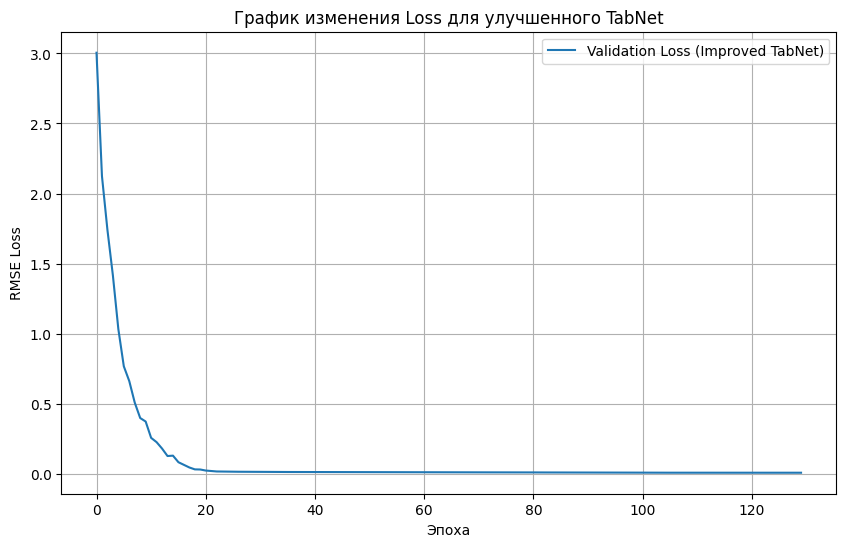

In [25]:
losses_improved = tabnet_improved.history['loss']

plt.figure(figsize=(10, 6))
plt.plot(losses_improved, label='Validation Loss (Improved TabNet)')
plt.title('График изменения Loss для улучшенного TabNet')
plt.xlabel('Эпоха')
plt.ylabel('RMSE Loss')
plt.legend()
plt.grid(True)
plt.show()


Новый оптимизатор

In [26]:
from torch.optim.lr_scheduler import OneCycleLR

tabnet_onecycle = TabNetRegressor(
    n_d=32, n_a=32,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-2,
    optimizer_fn=torch.optim.AdamW,
    optimizer_params=dict(lr=0.005, weight_decay=1e-5),
    scheduler_fn=OneCycleLR,
    scheduler_params=dict(
        max_lr=0.005,
        steps_per_epoch=int(X_train_scaled.shape[0] / 512),
        epochs=300,
        anneal_strategy='cos',  
        div_factor=10,
        final_div_factor=10000
    ),
    verbose=10,
    seed=42
)


/opt/homebrew/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [27]:
tabnet_onecycle.fit(
    X_train=X_train_scaled, y_train=y_train_np,
    eval_set=[(X_test_scaled, y_test_np)],
    eval_name=['test'],
    eval_metric=['rmse'],
    max_epochs=300,
    patience=30,
    batch_size=512,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)


epoch 0  | loss: 4.80009 | test_rmse: 3.53939 |  0:00:00s
epoch 10 | loss: 3.01258 | test_rmse: 16.99314|  0:00:09s
epoch 20 | loss: 2.2812  | test_rmse: 11.11753|  0:00:19s
epoch 30 | loss: 1.68452 | test_rmse: 10.40984|  0:00:28s

Early stopping occurred at epoch 30 with best_epoch = 0 and best_test_rmse = 3.53939


/opt/homebrew/lib/python3.11/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Результаты на тестовой выборке для TabNet с OneCycle:
MSE: 12.527316461340773
RMSE: 3.5393949287047315
R^2: -1649.1379968334481


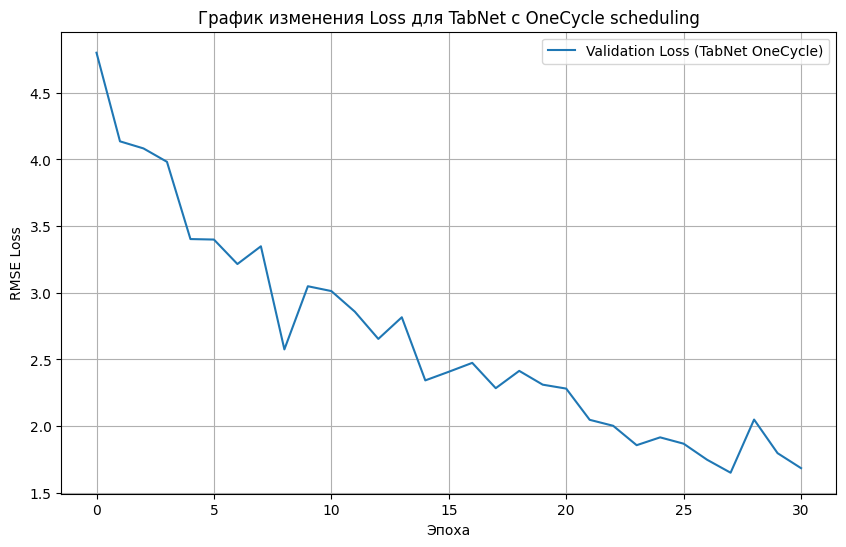

In [28]:
y_pred_tabnet_onecycle = tabnet_onecycle.predict(X_test_scaled).flatten()

mse_tabnet_onecycle = mean_squared_error(y_test, y_pred_tabnet_onecycle)
rmse_tabnet_onecycle = np.sqrt(mse_tabnet_onecycle)
r2_tabnet_onecycle = r2_score(y_test, y_pred_tabnet_onecycle)

print("\nРезультаты на тестовой выборке для TabNet с OneCycle:")
print("MSE:", mse_tabnet_onecycle)
print("RMSE:", rmse_tabnet_onecycle)
print("R^2:", r2_tabnet_onecycle)

losses_onecycle = tabnet_onecycle.history['loss']

plt.figure(figsize=(10, 6))
plt.plot(losses_onecycle, label='Validation Loss (TabNet OneCycle)')
plt.title('График изменения Loss для TabNet с OneCycle scheduling')
plt.xlabel('Эпоха')
plt.ylabel('RMSE Loss')
plt.legend()
plt.grid(True)
plt.show()


In [29]:
tabnet_dropout = TabNetRegressor(
    n_d=24, n_a=24,
    n_steps=5,
    gamma=2.0,         
    lambda_sparse=1e-1,
    optimizer_fn=torch.optim.AdamW,
    optimizer_params=dict(lr=0.005, weight_decay=1e-4),
    verbose=10,
    seed=42
)

tabnet_dropout.fit(
    X_train=X_train_scaled, y_train=y_train_np,
    eval_set=[(X_test_scaled, y_test_np)],
    eval_name=['test'],
    eval_metric=['rmse'],
    max_epochs=300,
    patience=30,
    batch_size=512,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)


/opt/homebrew/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 5.01642 | test_rmse: 1.62373 |  0:00:00s
epoch 10 | loss: 0.57067 | test_rmse: 12.64728|  0:00:09s
epoch 20 | loss: 0.26263 | test_rmse: 2.47148 |  0:00:18s
epoch 30 | loss: 0.07322 | test_rmse: 0.28434 |  0:00:31s
epoch 40 | loss: 0.05344 | test_rmse: 0.16039 |  0:00:42s
epoch 50 | loss: 0.04549 | test_rmse: 0.13177 |  0:00:51s
epoch 60 | loss: 0.03716 | test_rmse: 0.06176 |  0:01:00s
epoch 70 | loss: 0.02876 | test_rmse: 0.06878 |  0:01:09s
epoch 80 | loss: 0.02552 | test_rmse: 1.00445 |  0:01:18s
epoch 90 | loss: 0.0226  | test_rmse: 0.1106  |  0:01:27s

Early stopping occurred at epoch 95 with best_epoch = 65 and best_test_rmse = 0.05657


/opt/homebrew/lib/python3.11/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Результаты на тестовой выборке для TabNet с усиленным sparsity:
MSE: 0.003199687452866091
RMSE: 0.05656577987499237
R^2: 0.578526984589286


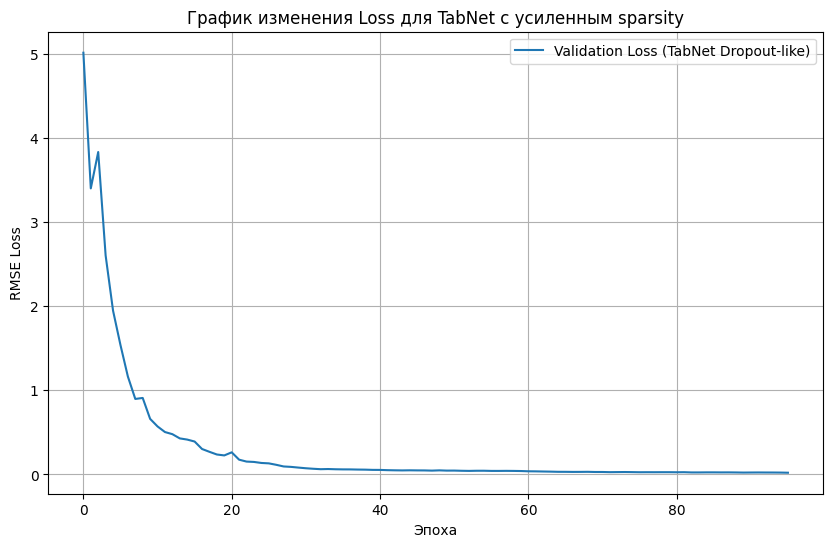

In [30]:
y_pred_tabnet_dropout = tabnet_dropout.predict(X_test_scaled).flatten()

mse_tabnet_dropout = mean_squared_error(y_test, y_pred_tabnet_dropout)
rmse_tabnet_dropout = np.sqrt(mse_tabnet_dropout)
r2_tabnet_dropout = r2_score(y_test, y_pred_tabnet_dropout)

print("\nРезультаты на тестовой выборке для TabNet с усиленным sparsity:")
print("MSE:", mse_tabnet_dropout)
print("RMSE:", rmse_tabnet_dropout)
print("R^2:", r2_tabnet_dropout)

losses_dropout = tabnet_dropout.history['loss']

plt.figure(figsize=(10, 6))
plt.plot(losses_dropout, label='Validation Loss (TabNet Dropout-like)')
plt.title('График изменения Loss для TabNet с усиленным sparsity')
plt.xlabel('Эпоха')
plt.ylabel('RMSE Loss')
plt.legend()
plt.grid(True)
plt.show()


CosineDecay для MLP

In [31]:
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=1000, 
    alpha=0.01         
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)


In [32]:
history_cosine = model.fit(
    X_train_scaled, y_train.values,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr], 
    verbose=1
)


Epoch 1/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0043 - mae: 0.0439 - val_loss: 0.0066 - val_mae: 0.0547 - learning_rate: 9.6967e-04
Epoch 2/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0048 - mae: 0.0438 - val_loss: 0.0044 - val_mae: 0.0414 - learning_rate: 8.8241e-04
Epoch 3/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0043 - mae: 0.0407 - val_loss: 0.0042 - val_mae: 0.0424 - learning_rate: 7.4890e-04
Epoch 4/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0043 - mae: 0.0411 - val_loss: 0.0058 - val_mae: 0.0507 - learning_rate: 5.8551e-04
Epoch 5/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0041 - mae: 0.0413 - val_loss: 0.0040 - val_mae: 0.0432 - learning_rate: 4.1225e-04
Epoch 6/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0035 - mae: 0.0386 - val_loss: 0.0041 - val_mae: 0.0446 - learning_rate: 2.5035e-04
Epoch 7/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0032 - mae: 0.0384 - val_loss: 0.0033 - val_mae: 0.0404

In [33]:
y_pred_mlp_cosine = model.predict(X_test_scaled).flatten()

mse_mlp_cosine = mean_squared_error(y_test, y_pred_mlp_cosine)
rmse_mlp_cosine = np.sqrt(mse_mlp_cosine)
r2_mlp_cosine = r2_score(y_test, y_pred_mlp_cosine)

print("\nРезультаты для MLP с CosineDecay scheduler:")
print("MSE:", mse_mlp_cosine)
print("RMSE:", rmse_mlp_cosine)
print("R^2:", r2_mlp_cosine)


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step

Результаты для MLP с CosineDecay scheduler:
MSE: 0.005308818428893868
RMSE: 0.07286163893911438
R^2: 0.3007055393833463


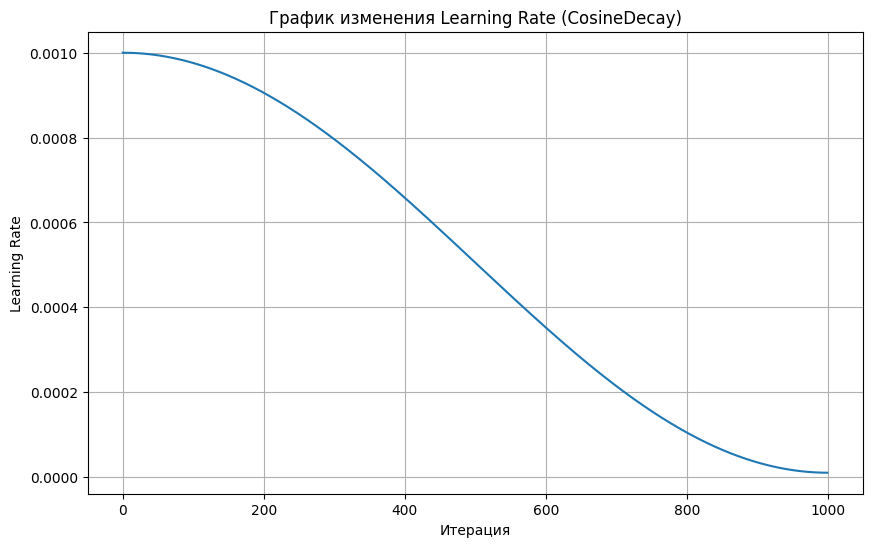

In [34]:
lrs = [lr_schedule(step) for step in range(1000)]

plt.figure(figsize=(10, 6))
plt.plot(lrs)
plt.title('График изменения Learning Rate (CosineDecay)')
plt.xlabel('Итерация')
plt.ylabel('Learning Rate')
plt.grid(True)
plt.show()


ExponentialDecay

In [35]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=100,         
    decay_rate=0.9,          
    staircase=True            
)


In [36]:
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)


In [37]:
history_exp_decay = model.fit(
    X_train_scaled, y_train.values,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],  
    verbose=1
)


Epoch 1/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0042 - mae: 0.0420 - val_loss: 0.0067 - val_mae: 0.0530
Epoch 2/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0045 - mae: 0.0410 - val_loss: 0.0053 - val_mae: 0.0489
Epoch 3/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0044 - mae: 0.0417 - val_loss: 0.0042 - val_mae: 0.0425
Epoch 4/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0042 - mae: 0.0402 - val_loss: 0.0041 - val_mae: 0.0417
Epoch 5/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0043 - mae: 0.0418 - val_loss: 0.0053 - val_mae: 0.0509
Epoch 6/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0040 - mae: 0.0399 - val_loss: 0.0041 - val_mae: 0.0414
Epoch 7/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0037 - mae: 0.0388 - val_loss: 0.0064 - val_mae: 0.0566
Epoch 8/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0037 - mae: 0.0394 - val_loss: 0.0036 - val_mae: 0.0397
Epoch 9/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

In [38]:
y_pred_mlp_exp_decay = model.predict(X_test_scaled).flatten()

mse_mlp_exp_decay = mean_squared_error(y_test, y_pred_mlp_exp_decay)
rmse_mlp_exp_decay = np.sqrt(mse_mlp_exp_decay)
r2_mlp_exp_decay = r2_score(y_test, y_pred_mlp_exp_decay)

print("\nРезультаты для MLP с ExponentialDecay scheduler:")
print("MSE:", mse_mlp_exp_decay)
print("RMSE:", rmse_mlp_exp_decay)
print("R^2:", r2_mlp_exp_decay)


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step

Результаты для MLP с ExponentialDecay scheduler:
MSE: 0.00514348767382715
RMSE: 0.0717181125924766
R^2: 0.3224834326634173


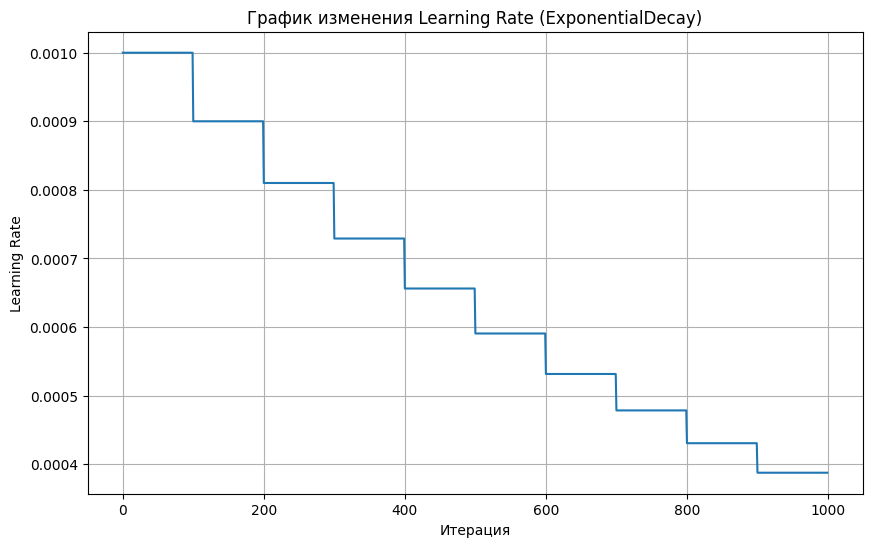

In [39]:
lrs = [lr_schedule(step) for step in range(1000)]

plt.figure(figsize=(10, 6))
plt.plot(lrs)
plt.title('График изменения Learning Rate (ExponentialDecay)')
plt.xlabel('Итерация')
plt.ylabel('Learning Rate')
plt.grid(True)
plt.show()


| Модель                                   | MSE       | RMSE      | R²          |
|:-----------------------------------------|:----------|:----------|:------------|
| Базовая нейронная сеть (MLP)              | 0.00228   | 0.04779   | 0.69921     |
| TabNet с усиленным sparsity               | 0.00320   | 0.05657   | 0.57853     |
| MLP с ExponentialDecay scheduler          | 0.00514   | 0.07172   | 0.32248     |
| MLP с CosineDecay scheduler               | 0.00531   | 0.07286   | 0.30071     |
| Улучшенный TabNet                        | 0.00727   | 0.08525   | 0.04261     |
| Базовый TabNet                           | 0.00889   | 0.09428   | -0.17090    |
| Улучшенная нейронная сеть (MLP+)          | 0.07913   | 0.28130   | -9.42322    |
| TabNet с OneCycle scheduling              | 12.52732  | 3.53939   | -1649.13800 |
